# How are in-demand skills trending for Top 5 Roles (Business Analyst, Software Engineer and Data Analyst, Engineer and Scientist)?

## Methology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

## Import Libraries and Dataset

In [2]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter

#Load dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Group the Skills by Month

Select only those job postings that are for top 5 roles and the job country is in Southeast Asia. Then extract the month from each job's posting date to see when jobs are listed. Next, converts a column that lists skills into a usable list format. Finally, it rearranges the data so that each skill from the list gets its own row.

In [4]:
# Countries belong to Southeast Asia
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [5]:
# Look up the top 5 job titles
top5_jobs = df['job_title_short'].value_counts().head().index.to_list()

top5_jobs

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Business Analyst',
 'Software Engineer']

In [16]:
# Skill count per month for top 5 jobs
df_SEA = df[(df['job_title_short'].isin(top5_jobs)) & (df['job_country'].isin(countries))].copy()

df_SEA['job_posted_month_no'] = df_SEA['job_posted_date'].dt.month

# Explode job_skills column
df_SEA_explode = df_SEA.explode('job_skills')

df_SEA_explode[['job_title_short', 'job_skills']].head()

,job_title_short,job_skills
44,Data Scientist,python
44,Data Scientist,java
44,Data Scientist,scala
76,Data Analyst,sql
76,Data Analyst,python


## Pivot in Preparation for Plotting

Create a pivot table from the df_SEA_explode, setting 'month' as the index, job_skills as the columns, and fills missing entries with zero.

In [7]:
# Group by month and job_skills
df_SEA_pivot = df_SEA_explode.pivot_table(
                                            index='job_posted_month_no'
                                            , columns='job_skills'
                                            , aggfunc='size'
                                            , fill_value=0)
df_SEA_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,168,5,64,40,53,1,7,2,9,4,...,0,101,1,259,0,0,0,2,17,6
2,128,2,44,18,37,0,2,1,12,4,...,0,76,1,172,0,0,0,0,8,4
3,107,3,63,29,50,0,2,5,11,1,...,0,88,1,185,0,1,0,0,9,5
4,135,1,64,21,48,2,4,3,13,2,...,0,88,3,196,0,0,0,0,21,5
5,111,0,49,11,22,0,2,1,6,0,...,0,65,3,170,0,2,0,0,20,1
6,154,5,50,26,37,0,1,4,5,1,...,1,68,4,198,0,0,0,0,17,4
7,160,3,57,24,31,0,2,4,10,0,...,0,114,3,200,0,0,0,0,8,3
8,170,1,48,25,33,0,8,6,11,1,...,0,101,1,237,0,0,0,0,15,4
9,106,1,30,13,15,0,10,1,8,0,...,0,66,3,174,1,0,0,1,14,13


## Sort columns by count and change month numbers to names

It adds a new row labeled Total that sums up counts across all months for each skill. Finally, it orders the cokumns based on the total counts, displaying them from highest to lowest, and shows the updated pivot table.

In [8]:
# Sort by column
df_SEA_pivot.loc['Total'] = df_SEA_pivot.sum() 

df_SEA_pivot = df_SEA_pivot[df_SEA_pivot.loc['Total'].sort_values(ascending=False).index]

df_SEA_pivot = df_SEA_pivot.drop(['Total'])

df_SEA_pivot


job_skills,sql,python,excel,tableau,power bi,r,aws,spark,java,azure,...,pascal,workfront,symfony,lisp,capacitor,f#,rocketchat,shogun,sqlserver,webex
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,2436,2105,1171,921,689,772,629,731,588,570,...,0,0,0,0,1,0,1,0,0,0
2,1494,1294,746,539,427,440,388,378,365,355,...,0,0,1,0,0,0,0,0,0,0
3,1757,1489,869,719,509,510,478,440,446,437,...,2,0,0,0,0,0,0,0,0,0
4,1632,1341,960,644,445,459,413,387,426,400,...,0,0,0,1,0,0,0,0,0,0
5,1431,1288,741,586,426,454,356,371,343,352,...,0,0,0,0,0,0,0,0,0,0
6,1766,1485,901,682,513,487,480,469,390,455,...,0,0,0,0,0,0,0,0,0,1
7,1874,1594,871,759,601,522,514,414,429,435,...,0,0,0,0,0,0,0,0,0,0
8,2037,1774,1007,835,614,560,563,508,455,466,...,0,0,0,0,0,0,0,0,0,0
9,1278,1121,695,549,465,368,363,325,281,304,...,0,1,0,0,0,0,0,0,0,0


## Plot the Monthly Skill Counts

Plot a line chart of the top 5 skills for top 5 roles, indexed by month. It selects the first five columns and plots them.

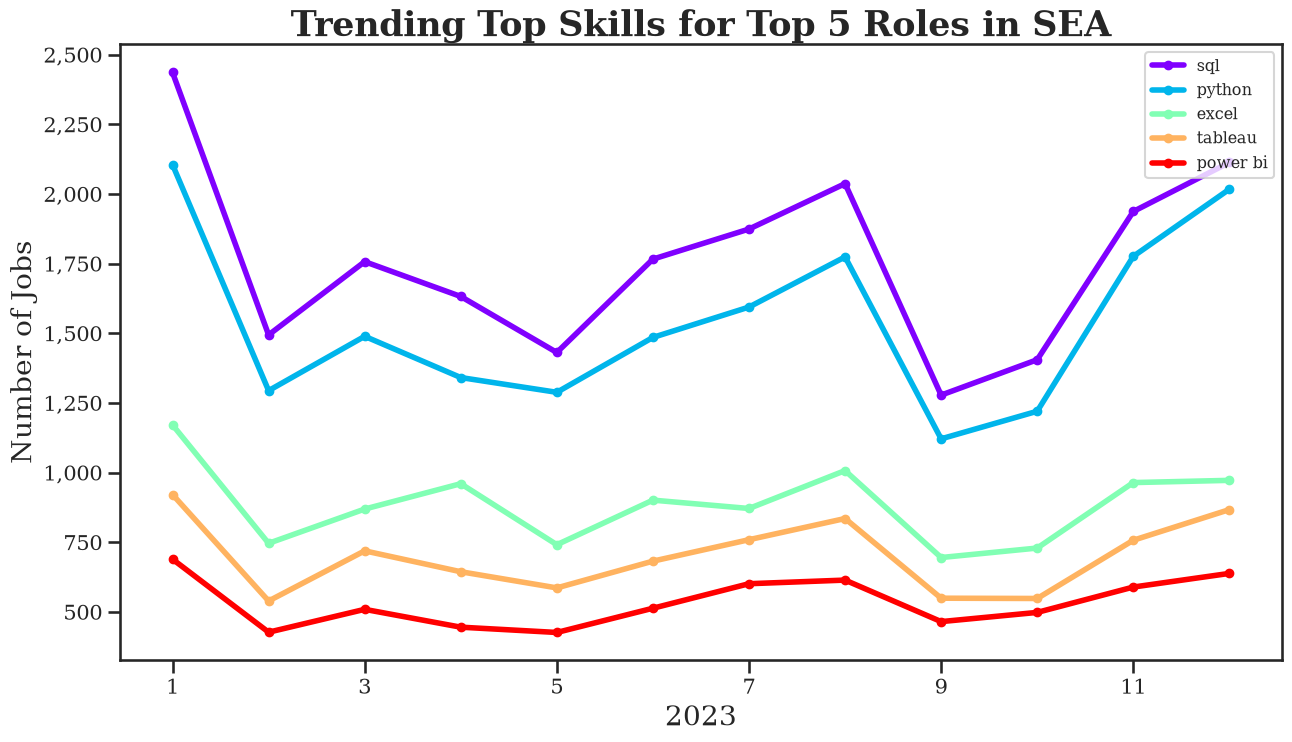

In [15]:
df_SEA_pivot.iloc[:, :5].plot(
                                kind='line'
                                , linewidth = 4
                                , linestyle = '-'
                                , colormap = 'rainbow'
                                , markersize = 6
                                , marker = 'o' 
                                , figsize = (15, 8))

plt.title(
            'Trending Top Skills for Top 5 Roles in SEA'
            , fontdict={'fontsize': 25, 'fontweight': 'bold'})

plt.ylabel(
            'Number of Jobs'
            , fontdict={'fontsize': 20})

plt.xlabel(
            '2023'
            , fontdict={'fontsize': 20})


plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y):,}'))
plt.legend(loc='upper right')

plt.gca().tick_params(axis='x', labelsize = 15)
plt.gca().tick_params(axis='y', labelsize = 15)

plt.show()

## Calculate Percentage of Total Jobs

Calculates the total number of entries for each month in df_SEA by grouping the data by 'month' and counting the number of occurrences in each group, storing the results in df_SEA_totals. This is needed to compute the percentages.

In [10]:
# Get monthly totals
df_SEA_totals = df_SEA.groupby('job_posted_month_no').size()

df_SEA_totals

job_posted_month_no
1     5256
2     3120
3     3607
4     3768
5     3024
6     3592
7     3797
8     4265
9     3000
10    3259
11    4436
12    4683
dtype: int64

These codes following calculate the percentage of each skill's occurrence for each month by dividing the total jobs of all skills of df_SEA_totals. The new DataFrame, df_SEA_pivot_percent, shows skill distributions as percentage of total monthly job entries for each demanded skill.

In [11]:
# Divide 12 rows of df_SEA_pivot by df_SEA_totals
df_SEA_pivot_percent = df_SEA_pivot.div(df_SEA_totals/100, axis=0)

df_SEA_pivot_percent

job_skills,sql,python,excel,tableau,power bi,r,aws,spark,java,azure,...,pascal,workfront,symfony,lisp,capacitor,f#,rocketchat,shogun,sqlserver,webex
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,46.347032,40.049467,22.279300,17.522831,13.108828,14.687976,11.967275,13.907915,11.187215,10.844749,...,0.000000,0.000000,0.000000,0.000000,0.019026,0.000000,0.019026,0.000000,0.000000,0.00000
2,47.884615,41.474359,23.910256,17.275641,13.685897,14.102564,12.435897,12.115385,11.698718,11.378205,...,0.000000,0.000000,0.032051,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
3,48.710840,41.280843,24.092043,19.933463,14.111450,14.139174,13.252010,12.198503,12.364846,12.115331,...,0.055448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,43.312102,35.589172,25.477707,17.091295,11.809979,12.181529,10.960722,10.270701,11.305732,10.615711,...,0.000000,0.000000,0.000000,0.026539,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
5,47.321429,42.592593,24.503968,19.378307,14.087302,15.013228,11.772487,12.268519,11.342593,11.640212,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
6,49.164811,41.341871,25.083519,18.986637,14.281737,13.557906,13.363029,13.056793,10.857461,12.667038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.02784
7,49.354754,41.980511,22.939162,19.989465,15.828285,13.747696,13.537003,10.903345,11.298393,11.456413,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
8,47.760844,41.594373,23.610785,19.577960,14.396249,13.130129,13.200469,11.910903,10.668230,10.926143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
9,42.600000,37.366667,23.166667,18.300000,15.500000,12.266667,12.100000,10.833333,9.366667,10.133333,...,0.000000,0.033333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [12]:
# Change month number to month name
df_SEA_pivot_percent = df_SEA_pivot_percent.reset_index()

df_SEA_pivot_percent['job_posted_month'] = df_SEA_pivot_percent['job_posted_month_no'].apply(lambda month: pd.to_datetime(month, format='%m').strftime('%b'))

df_SEA_pivot_percent  = df_SEA_pivot_percent.set_index('job_posted_month')

df_SEA_pivot_percent = df_SEA_pivot_percent.drop(columns=['job_posted_month_no'])

df_SEA_pivot_percent

job_skills,sql,python,excel,tableau,power bi,r,aws,spark,java,azure,...,pascal,workfront,symfony,lisp,capacitor,f#,rocketchat,shogun,sqlserver,webex
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,46.347032,40.049467,22.279300,17.522831,13.108828,14.687976,11.967275,13.907915,11.187215,10.844749,...,0.000000,0.000000,0.000000,0.000000,0.019026,0.000000,0.019026,0.000000,0.000000,0.00000
Feb,47.884615,41.474359,23.910256,17.275641,13.685897,14.102564,12.435897,12.115385,11.698718,11.378205,...,0.000000,0.000000,0.032051,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Mar,48.710840,41.280843,24.092043,19.933463,14.111450,14.139174,13.252010,12.198503,12.364846,12.115331,...,0.055448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Apr,43.312102,35.589172,25.477707,17.091295,11.809979,12.181529,10.960722,10.270701,11.305732,10.615711,...,0.000000,0.000000,0.000000,0.026539,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
May,47.321429,42.592593,24.503968,19.378307,14.087302,15.013228,11.772487,12.268519,11.342593,11.640212,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Jun,49.164811,41.341871,25.083519,18.986637,14.281737,13.557906,13.363029,13.056793,10.857461,12.667038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.02784
Jul,49.354754,41.980511,22.939162,19.989465,15.828285,13.747696,13.537003,10.903345,11.298393,11.456413,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Aug,47.760844,41.594373,23.610785,19.577960,14.396249,13.130129,13.200469,11.910903,10.668230,10.926143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Sep,42.600000,37.366667,23.166667,18.300000,15.500000,12.266667,12.100000,10.833333,9.366667,10.133333,...,0.000000,0.033333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


## Plot Monthly Skill Demand

Create a line plot for the top five skills of top 5 roles, shown as percentage of the total job postings per month, using the first 5 columns of the df_SEA_pivot_percent DataFrame. Furthermore, the legend has to be removed outside of the plot for readability.

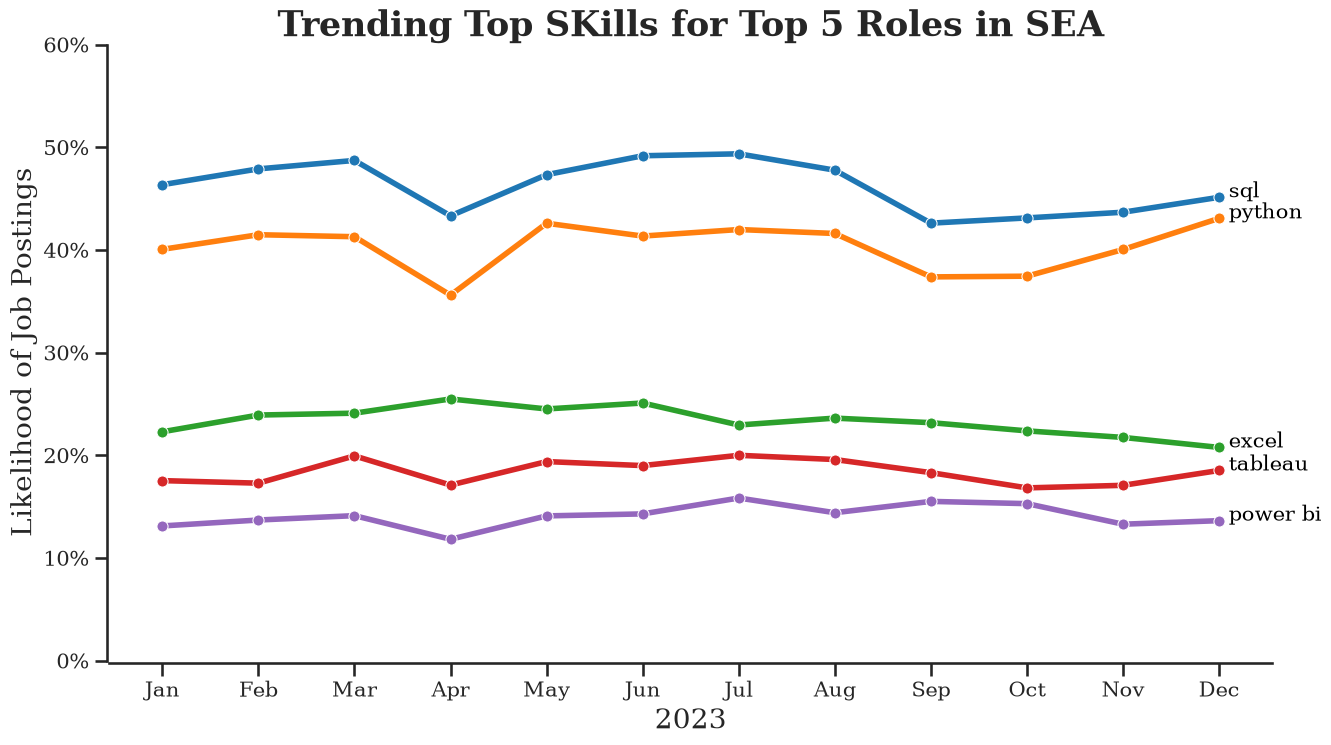

In [14]:
df_plot = df_SEA_pivot_percent.iloc[:, :5]

fig, ax = plt.subplots(figsize = (15, 8))
sns.set_theme(
                style='ticks'
                , palette = 'tab10'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

sns.lineplot(
                data = df_plot
                , dashes=False
                , linewidth = 4
                , linestyle = '-'
                , markersize = 8
                , marker = 'o'
                , color = 'black'
                , legend=False)

sns.despine(offset=2) # remove top and right spines

plt.title(
            'Trending Top SKills for Top 5 Roles in SEA'
            , fontdict={'fontsize': 25, 'fontweight': 'bold'})

plt.xlabel(
            '2023'
            , fontdict={'fontsize': 20})

plt.ylabel(
            'Likelihood of Job Postings'
            , fontdict={'fontsize': 20})

plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.gca().tick_params(axis='x', labelsize = 15)
plt.gca().tick_params(axis='y', labelsize = 15)
plt.ylim(0, 60)

# Annotate the plot with the top 5 skills using plt.text()
for index in range(5):
    plt.text(
                len(df_plot.index) - 0.9
                , df_plot.iloc[-1, index]
                , df_plot.columns[index]
                , color = 'black'
                , fontdict={'fontsize': 15})

plt.show()